# **1. Persiapan Lingkungan, Library, dan Autentikasi API**
Saya memulai langkah awal dengan menginstal dan memuat seluruh pustaka (library) yang dibutuhkan untuk manipulasi data, pemodelan, hingga deployment. Di sel ini, saya juga melakukan autentikasi ke Hugging Face dan Kaggle agar saya memiliki akses penuh untuk mengunduh dataset dan mengunggah model nantinya.

---

In [2]:
# Install semua library yang dibutuhkan di awal
!pip install -q xgboost scikit-learn pandas matplotlib huggingface_hub kaggle joblib imbalanced-learn lazypredict

import os
import glob
import getpass
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import notebook_login, HfApi
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

print("=== 1. Autentikasi Hugging Face ===")
print("Pastikan kamu menggunakan token dengan akses 'WRITE'.")
notebook_login()

print("\n=== 2. Autentikasi Kaggle ===")
kaggle_user = input("Masukkan Username Kaggle kamu: ")
kaggle_key = getpass.getpass("Masukkan API Key Kaggle kamu: ")

# Mendaftarkan kredensial ke environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_user
os.environ['KAGGLE_KEY'] = kaggle_key

print("✅ Autentikasi Kaggle dan Hugging Face berhasil disiapkan!")

=== 1. Autentikasi Hugging Face ===
Pastikan kamu menggunakan token dengan akses 'WRITE'.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



=== 2. Autentikasi Kaggle ===
Masukkan Username Kaggle kamu: ripanripan
Masukkan API Key Kaggle kamu: ··········
✅ Autentikasi Kaggle dan Hugging Face berhasil disiapkan!


# **2. Akuisisi Dataset dan Analisis Eksploratif (EDA)**
Pada tahap ini, dataset diunduh langsung dari Kaggle (`mlg-ulb/creditcardfraud`) ke dalam direktori lokal. Setelah data berhasil dimuat, analisis eksploratif dilakukan untuk meninjau struktur data dan memvisualisasikan distribusi kelas. Langkah ini bertujuan untuk mengukur skala ketimpangan (*imbalance*) antara transaksi normal dan *fraud*.

---

Masukkan format <username>/<nama-dataset> dari Kaggle (tekan Enter untuk default 'mlg-ulb/creditcardfraud'): 

⏳ Sedang mengunduh dataset: mlg-ulb/creditcardfraud dari Kaggle...
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
✅ Unduhan dan ekstraksi selesai di folder: creditcardfraud/
⏳ Memuat file dataset otomatis: creditcardfraud/creditcard.csv ...

✅ Dataset berhasil dimuat!

🔍 MELAKUKAN ANALISIS DATA (EDA)...
------------------------------
 - Normal: 284315 transaksi (99.827%)
 - Fraud: 492 transaksi (0.173%)


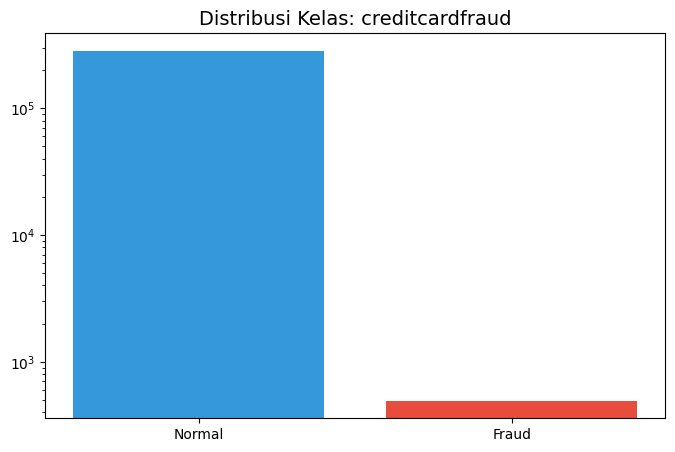

------------------------------

--- INFO STRUKTUR DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null 

In [3]:
# Meminta input path dataset Kaggle
nama_dataset_kaggle = input("Masukkan format <username>/<nama-dataset> dari Kaggle (tekan Enter untuk default 'mlg-ulb/creditcardfraud'): ")
if not nama_dataset_kaggle:
    nama_dataset_kaggle = "mlg-ulb/creditcardfraud"

print(f"\n⏳ Sedang mengunduh dataset: {nama_dataset_kaggle} dari Kaggle...")
nama_folder = nama_dataset_kaggle.split('/')[-1]

try:
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(nama_dataset_kaggle, path=nama_folder, unzip=True)
    print(f"✅ Unduhan dan ekstraksi selesai di folder: {nama_folder}/")
except Exception as e:
    print(f"❌ Gagal mengunduh dataset. Error: {e}")

csv_files = glob.glob(os.path.join(nama_folder, '*.csv'))

if not csv_files:
    print(f"\n❌ Error Kritis: Tidak ada file CSV yang ditemukan di folder '{nama_folder}'.")
else:
    file_path = max(csv_files, key=os.path.getsize)
    print(f"⏳ Memuat file dataset otomatis: {file_path} ...")
    df = pd.read_csv(file_path)
    print("\n✅ Dataset berhasil dimuat!")

    target_col = None
    possible_targets = ['Class', 'isFraud', 'isfraud', 'fraud', 'Fraud', 'is_fraud']
    for col in possible_targets:
        if col in df.columns:
            target_col = col
            break
    if target_col is None:
        target_col = input("Ketikkan nama kolom target (misal: Class) secara manual: ")

    print("\n🔍 MELAKUKAN ANALISIS DATA (EDA)...")
    print("-" * 30)
    distribusi = df[target_col].value_counts()
    label_names = {0: 'Normal', 1: 'Fraud'}

    for label_code, jumlah in distribusi.items():
        nama_label = label_names.get(label_code, f'Kelas {label_code}')
        persentase = (jumlah / len(df)) * 100
        print(f" - {nama_label}: {jumlah} transaksi ({persentase:.3f}%)")

    plt.figure(figsize=(8, 5))
    colors = ['#3498db', '#e74c3c']
    x_labels = [label_names.get(code, f'Kelas {code}') for code in distribusi.index]
    bars = plt.bar(x_labels, distribusi.values, color=colors[:len(distribusi)])
    plt.title(f"Distribusi Kelas: {nama_folder}", fontsize=14)
    plt.yscale('log')
    plt.show()
    print("-" * 30)
    print("\n--- INFO STRUKTUR DATASET ---")
    print(df.info())

# **3. Preprocessing dan Split Data**
Untuk menjaga objektivitas evaluasi model, saya membagi dataset menjadi data latih (*train set*) dan data uji (*test set*). Selain itu, saya juga melakukan *scaling* menggunakan `RobustScaler` pada fitur-fitur yang memiliki perbedaan rentang nilai yang terlalu jauh, seperti `Time` dan `Amount`.

---

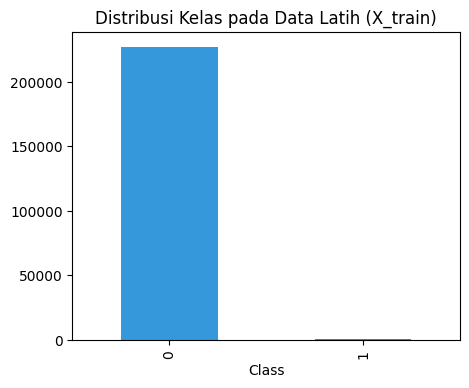

In [5]:
X = df.drop(columns=[target_col])
y = df[target_col]

# Split data: 20% untuk ujian murni (Test Set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling fitur yang nilainya memiliki ketimpangan ekstrem
scaler = RobustScaler()
if 'Time' in X_train.columns and 'Amount' in X_train.columns:
    X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
    X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

# Visualisasi distribusi data latih (Opsional)
plt.figure(figsize=(5, 4))
y_train.value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title("Distribusi Kelas pada Data Latih (X_train)")
plt.show()

# **4. Pelatihan Model Utama dan Evaluasi Performa**
Di sini, saya melatih algoritma Extra Trees menggunakan data latih asli (tanpa manipulasi *resampling*). Setelah itu, saya menguji model pada data uji murni untuk mendapatkan metrik evaluasi yang objektif. Saya juga melakukan analisis *F1-Score* antara data latih dan data uji guna memastikan model tidak terjebak pada fase *Overfitting* maupun *Underfitting*.

---

⏳ Menginisialisasi model Extra Trees...
⏳ Sedang melatih model dengan data latih asli...
✅ Model Extra Trees selesai dilatih!

⏳ Melakukan prediksi pada data latih dan data uji...

📊 HASIL EVALUASI MODEL (TEST SET):
-------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.95      0.84      0.89        98

    accuracy                           1.00     56962
   macro avg       0.98      0.92      0.95     56962
weighted avg       1.00      1.00      1.00     56962

-------------------------------------------------------


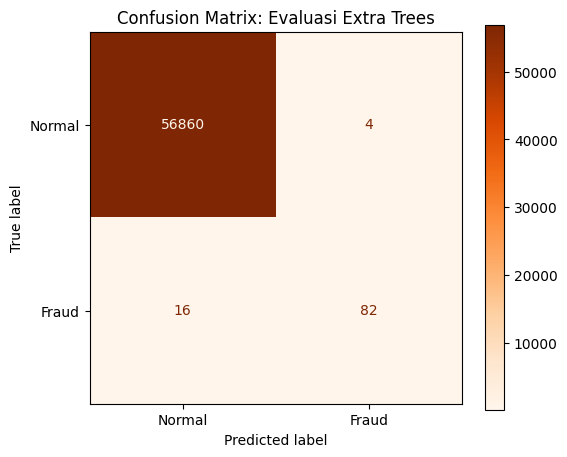


⏳ Mengecek indikasi Overfitting / Underfitting...
-------------------------------------------------------
📊 PERBANDINGAN PERFORMA (TRAIN vs TEST)
-------------------------------------------------------
Akurasi  (Train) : 1.0000  |  Akurasi  (Test) : 0.9996
F1-Score (Train) : 1.0000  |  F1-Score (Test) : 0.9456
-------------------------------------------------------
✅ KESIMPULAN: Model GOOD FIT!
Perbedaan performa antara Train dan Test sangat wajar dan stabil. Model siap diandalkan.


In [6]:
print("⏳ Menginisialisasi model Extra Trees...")
# n_jobs=-1 tetap digunakan agar semua core CPU bekerja maksimal
model_et = ExtraTreesClassifier(random_state=42, n_jobs=-1)

print("⏳ Sedang melatih model dengan data latih asli...")
model_et.fit(X_train, y_train)
print("✅ Model Extra Trees selesai dilatih!")

print("\n⏳ Melakukan prediksi pada data latih dan data uji...")
y_train_pred = model_et.predict(X_train)
y_pred = model_et.predict(X_test)

print("\n📊 HASIL EVALUASI MODEL (TEST SET):")
print("-" * 55)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
print("-" * 55)

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Oranges', values_format='d', ax=ax)
plt.title("Confusion Matrix: Evaluasi Extra Trees", fontsize=12)
plt.show()

print("\n⏳ Mengecek indikasi Overfitting / Underfitting...")
# Menghitung F1-Score (Macro) dan Akurasi
train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_pred, average='macro')
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print("-" * 55)
print("📊 PERBANDINGAN PERFORMA (TRAIN vs TEST)")
print("-" * 55)
print(f"Akurasi  (Train) : {train_acc:.4f}  |  Akurasi  (Test) : {test_acc:.4f}")
print(f"F1-Score (Train) : {train_f1:.4f}  |  F1-Score (Test) : {test_f1:.4f}")
print("-" * 55)

# Logika Analisis Otomatis
selisih_f1 = train_f1 - test_f1

if train_f1 < 0.70 and test_f1 < 0.70:
    print("⚠️ KESIMPULAN: Ada indikasi UNDERFITTING.")
    print("Model kesulitan mempelajari pola data. Pertimbangkan untuk mencoba algoritma lain atau mengatur hyperparameter.")
elif selisih_f1 > 0.08:
    print("⚠️ KESIMPULAN: Ada indikasi OVERFITTING.")
    print("Performa di data latih lebih tinggi daripada data uji. Model cenderung 'menghafal' data latih.")
    print("Saran: Batasi kedalaman tree (max_depth) atau tingkatkan min_samples_split.")
else:
    print("✅ KESIMPULAN: Model GOOD FIT!")
    print("Perbedaan performa antara Train dan Test sangat wajar dan stabil. Model siap diandalkan.")

# **5. Analisis Fitur Penting, Packaging, dan Deployment**
Langkah terakhir adalah menganalisis fitur mana yang paling dominan dalam mendeteksi penipuan. Setelah itu, saya mengemas model dan objek *scaler* ke dalam satu berkas tunggal menggunakan `joblib`, lalu mengunggahnya langsung ke *Hugging Face Hub* agar model siap diintegrasikan pada tahap produksi.

---

🔍 MENGANALISIS FEATURE IMPORTANCE...


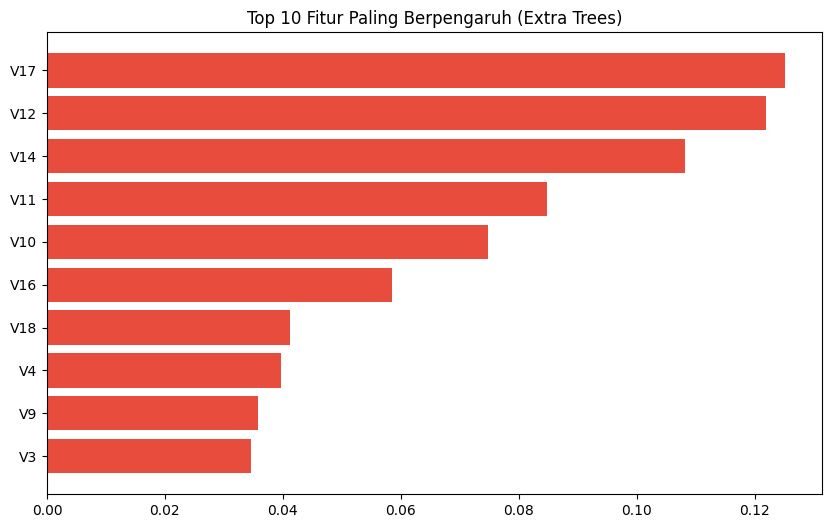


📦 PACKAGING MODEL & SCALER...

☁️ MENGUNGGAH KE HUGGING FACE HUB...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ection_et_bundle_v1.1.pkl: 100%|##########| 10.3MB / 10.3MB            


✅ BINGO! Model Extra Trees berhasil mengangkasa ke: https://huggingface.co/Ripanrz/credit-card-fraud-et-v1.1


In [7]:
print("🔍 MENGANALISIS FEATURE IMPORTANCE...")
importances = model_et.feature_importances_
feature_names = X.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df.head(10)['Feature'][::-1], feature_imp_df.head(10)['Importance'][::-1], color='#e74c3c')
plt.title('Top 10 Fitur Paling Berpengaruh (Extra Trees)')
plt.show()

print("\n📦 PACKAGING MODEL & SCALER...")
pipeline_bundle = {'scaler': scaler, 'model': model_et}
nama_file_bundle = 'fraud_detection_et_bundle_v1.1.pkl'
joblib.dump(pipeline_bundle, nama_file_bundle)

print("\n☁️ MENGUNGGAH KE HUGGING FACE HUB...")
# Ganti dengan username/repository Hugging Face milikmu
repo_id = "Ripanrz/credit-card-fraud-et-v1.1"

try:
    api = HfApi()
    api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)
    api.upload_file(
        path_or_fileobj=nama_file_bundle,
        path_in_repo=nama_file_bundle,
        repo_id=repo_id,
        repo_type="model"
    )
    print(f"\n✅ BINGO! Model Extra Trees berhasil mengangkasa ke: https://huggingface.co/{repo_id}")
except Exception as e:
    print(f"\n❌ Gagal mengunggah. Error: {e}")